In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from models_pipe import train_tree_models, evaluate_model, tsne_visual, extract_misclass
from data_preprocessing import radiomics_load, train_test_split, preprocess_train, preprocess_test
from models_pipe import train_pipe, cross_val
from pathlib import Path
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

In [2]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data/final_data.csv")
data

,MatchKey,Original File,Destination Folder,New File,SubjectKeyRadiology,ExamDate,file,is_liver_imaged,contrast,phase_timing,...,XRayExposure,ImageOrientationPatientDICOM,ConversionSoftware,ConversionSoftwareVersion,BodyPartExamined,RawImage,SliceThickness,AcquisitionTime_sec,DICOM_phase,exist_on_server
0,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz,../DICOM-batch1\NKI-d23231-00-0063\20120416 CT...,DICOM-batch1-kalina01,NET_0000_0000.nii.gz,NKI-d23231-00-0063,2012-04-16,NET_0000_0000.nii.gz,Partially,Arterial,Too Early,...,75.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,40231.70000,Arterial,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
1,NKI-d23231-00-0070_20150821_kalina01_0001.nii.gz,../DICOM-batch1\NKI-d23231-00-0070\20150821 CT...,DICOM-batch1-kalina01,NET_0001_0000.nii.gz,NKI-d23231-00-0070,2015-08-21,NET_0001_0000.nii.gz,Yes,Non-contrast,Non-contrast,...,38.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,LEVER,NaN,1.0,30853.90000,Non-contrast,NaN
2,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz,../DICOM-batch1\NKI-d23231-00-0036\20140218 CT...,DICOM-batch1-kalina01,NET_0002_0000.nii.gz,NKI-d23231-00-0036,2014-02-18,NET_0002_0000.nii.gz,Yes,Portal,Just Right,...,37.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,32599.60000,NaN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz,../DICOM-batch1\NKI-d23231-00-0071\20130924 CT...,DICOM-batch1-kalina01,NET_0003_0000.nii.gz,NKI-d23231-00-0071,2013-09-24,NET_0003_0000.nii.gz,Yes,Arterial,Just Right,...,84.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,45013.30692,NaN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
4,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz,../DICOM-batch1\NKI-d23231-00-0077\20141222 CT...,DICOM-batch1-kalina01,NET_0004_0000.nii.gz,NKI-d23231-00-0077,2014-12-22,NET_0004_0000.nii.gz,Yes,Portal,Just Right,...,74.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,51587.10418,Portal,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8330,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,../DICOM-batch3\NKI-d23231-00-0888\20220420 CT...,DICOM-batch3-kalina99,NET_5827_0000.nii.gz,NKI-d23231-00-0888,2022-04-20,NET_5827_0000.nii.gz,Yes,Portal,Just Right,...,98.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,54796.11932,Portal,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
8331,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,../DICOM-batch3\NKI-d23231-00-0888\20230424 CT...,DICOM-batch3-kalina99,NET_5828_0000.nii.gz,NKI-d23231-00-0888,2023-04-24,NET_5828_0000.nii.gz,Yes,Arterial,Just Right,...,175.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,43545.56100,Arterial,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
8332,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,../DICOM-batch3\NKI-d23231-00-0888\20230424 CT...,DICOM-batch3-kalina99,NET_5829_0000.nii.gz,NKI-d23231-00-0888,2023-04-24,NET_5829_0000.nii.gz,Yes,Portal,Just Right,...,168.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,43580.13800,NaN,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
8333,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz,../DICOM-batch3\NKI-d23231-00-0888\20230801 CT...,DICOM-batch3-kalina99,NET_5830_0000.nii.gz,NKI-d23231-00-0888,2023-08-01,NET_5830_0000.nii.gz,Yes,Arterial,Just Right,...,92.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,42200.65000,Arterial,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...


In [3]:
data_dir = Path("/projects/net_contrast_classification/contrast_phase/data/cleaned_data/final_data.csv")

features_dir = Path("/projects/net_contrast_classification/contrast_phase/Radiomics/features")

radiomics = radiomics_load(data_dir, features_dir)
radiomics

,image,SubjectKeyRadiology,phase_timing,contrast,organ,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,...,original_glcm_Correlation,original_glcm_Autocorrelation,original_glcm_ClusterTendency,original_glcm_DifferenceEntropy,original_glszm_ZoneEntropy,original_glszm_SmallAreaEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_SizeZoneNonUniformity,original_gldm_SmallDependenceEmphasis,original_gldm_DependenceNonUniformity
0,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,spleen,73.0,129.0,1.411073e+09,2.345055,28.0,...,0.331391,161.467821,4.317435,1.807917,5.579062,0.607571,789.747481,2234.026508,0.057494,8059.752032
1,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,kidney_right,35.0,174.0,2.051722e+09,3.368361,96.0,...,0.573631,172.405745,24.124352,2.463745,5.972511,0.623694,1069.817432,4300.504964,0.100165,11505.342655
2,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,kidney_left,29.0,175.0,1.875893e+09,3.462463,101.0,...,0.625287,168.789858,27.864372,2.459546,5.964703,0.651090,921.112624,4496.306967,0.102064,10496.241509
3,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,gallbladder,15.0,92.0,6.779767e+06,2.671679,44.0,...,0.277793,49.512989,6.008309,2.088526,5.214034,0.571997,22.650794,58.957672,0.102627,169.717503
4,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,liver,57.0,111.0,9.182282e+09,2.273400,28.0,...,0.304811,769.295507,3.639820,1.789879,5.516856,0.589709,7598.796877,15753.440790,0.049232,79966.681546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166655,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,portal_vein_and_splenic_vein,94.0,199.0,3.244518e+08,2.985268,54.0,...,0.441004,162.569181,11.146397,2.231316,5.916112,0.579998,180.277874,546.459272,0.132850,1009.163186
166656,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,iliac_artery_left,47.0,169.0,1.198564e+08,3.299687,60.0,...,0.538260,169.284619,19.404490,2.269254,6.271613,0.553009,87.013220,307.181303,0.143030,577.424611
166657,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,iliac_artery_right,47.0,167.0,2.443429e+08,3.426126,67.0,...,0.574321,193.314195,96.147512,2.481168,6.542065,0.607940,99.914074,464.976296,0.155215,700.690310
166658,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,iliac_vena_left,26.0,122.0,1.316743e+08,3.136003,42.0,...,0.626491,113.830952,18.455433,2.138249,6.222564,0.600864,131.003509,578.122807,0.110335,1047.527077


In [4]:
radiomics.info()

<class 'pandas.DataFrame'>
RangeIndex: 166660 entries, 0 to 166659
Data columns (total 34 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   image                                            166660 non-null  str    
 1   SubjectKeyRadiology                              164920 non-null  str    
 2   phase_timing                                     164920 non-null  str    
 3   contrast                                         166660 non-null  str    
 4   organ                                            166660 non-null  str    
 5   original_firstorder_10Percentile                 146636 non-null  float64
 6   original_firstorder_90Percentile                 146636 non-null  float64
 7   original_firstorder_Energy                       146636 non-null  float64
 8   original_firstorder_Entropy                      146636 non-null  float64
 9   original_firstorder_Interq

In [4]:
radiomics = radiomics[radiomics['SubjectKeyRadiology'].notna()]

In [5]:
train_data, test_data = train_test_split(radiomics, test_size=0.3, grouping="SubjectKeyRadiology")

meta_cols = list(train_data.iloc[:, :5].columns)

train_pipeline = preprocess_train(train_data, meta_cols, NA_filter_threshold=0.2, pca_components=30)

train_processed = train_pipeline["data_processed"]
X_train_pca = train_pipeline["X_pca"]
test_processed, X_test_pca = preprocess_test(test_data, meta_cols,train_pipeline)

# Contrast Classification

## Modeling and Evaluation

In [6]:
contrast_le = LabelEncoder()

X_train, y_train = train_processed.iloc[:, 4:], contrast_le.fit_transform(train_processed.contrast)
X_test, y_test = test_processed.iloc[:, 4:], contrast_le.fit_transform(test_processed.contrast)

print(f"Shape of train data: {X_train.shape}\nShape of train labels: {y_train.shape}")
print(f"Shape of test data: {X_test.shape}\nShape of test labels: {y_test.shape}")


Shape of train data: (5769, 211)
Shape of train labels: (5769,)
Shape of test data: (2477, 211)
Shape of test labels: (2477,)


In [7]:
models = train_tree_models(X_train, y_train)
GBT_pred,_ = evaluate_model(models["GBT"], X_test, y_test, contrast_le)

Accuracy of XGBClassifier: 0.97537

Classification report for XGBClassifier:
              precision    recall  f1-score   support

    Arterial       0.97      0.96      0.96       736
Non-contrast       0.99      1.00      1.00       616
      Portal       0.97      0.98      0.97      1125

    accuracy                           0.98      2477
   macro avg       0.98      0.98      0.98      2477
weighted avg       0.98      0.98      0.98      2477



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,705,0,31,736
Non-contrast,0,614,2,616
Portal,24,4,1097,1125
All,729,618,1130,2477


In [9]:
evaluate_model(models["DT"], X_test, y_test, contrast_le)

Accuracy of DecisionTreeClassifier: 0.95842

Classification report for DecisionTreeClassifier:
              precision    recall  f1-score   support

    Arterial       0.95      0.91      0.93       736
Non-contrast       1.00      1.00      1.00       616
      Portal       0.94      0.97      0.95      1125

    accuracy                           0.96      2477
   macro avg       0.96      0.96      0.96      2477
weighted avg       0.96      0.96      0.96      2477



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,672,0,64,736
Non-contrast,0,613,3,616
Portal,33,3,1089,1125
All,705,616,1156,2477


(array([2, 1, 2, ..., 2, 2, 2]), 0.9584174404521598)

In [10]:
evaluate_model(models["RF"], X_test, y_test, contrast_le)


Accuracy of RandomForestClassifier: 0.97457

Classification report for RandomForestClassifier:
              precision    recall  f1-score   support

    Arterial       0.98      0.94      0.96       736
Non-contrast       1.00      1.00      1.00       616
      Portal       0.96      0.99      0.97      1125

    accuracy                           0.97      2477
   macro avg       0.98      0.97      0.98      2477
weighted avg       0.97      0.97      0.97      2477



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,691,0,45,736
Non-contrast,0,613,3,616
Portal,12,3,1110,1125
All,703,616,1158,2477


(array([2, 1, 2, ..., 2, 2, 2]), 0.974566007266855)

In [11]:
# TEST ON A RANDOM SUBSET OF 20 FEATURES 

subset = np.random.choice(X_train.columns, 20, replace=False)
models = train_tree_models(X_train[subset], y_train)

model = models['GBT']
pred = model.predict(X_test[subset])

print(classification_report(y_test, pred, target_names=contrast_le.classes_))

              precision    recall  f1-score   support

    Arterial       0.95      0.93      0.94       736
Non-contrast       0.99      0.99      0.99       616
      Portal       0.95      0.97      0.96      1125

    accuracy                           0.96      2477
   macro avg       0.97      0.96      0.97      2477
weighted avg       0.96      0.96      0.96      2477



## Cross Validation

In [12]:
acc = cross_val(radiomics,
                 ["image", "SubjectKeyRadiology", "phase_timing", "contrast", "organ"],
                   class_name = "contrast",
                     model_name = "GBT")

Accuracy of XGBClassifier: 0.96422

Classification report for XGBClassifier:
              precision    recall  f1-score   support

    Arterial       0.95      0.93      0.94       496
Non-contrast       1.00      1.00      1.00       414
      Portal       0.95      0.97      0.96       739

    accuracy                           0.96      1649
   macro avg       0.97      0.97      0.97      1649
weighted avg       0.96      0.96      0.96      1649



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,462,0,34,496
Non-contrast,0,412,2,414
Portal,22,1,716,739
All,484,413,752,1649


Accuracy of XGBClassifier: 0.98110

Classification report for XGBClassifier:
              precision    recall  f1-score   support

    Arterial       0.98      0.97      0.97       493
Non-contrast       1.00      0.99      0.99       411
      Portal       0.97      0.99      0.98       736

    accuracy                           0.98      1640
   macro avg       0.98      0.98      0.98      1640
weighted avg       0.98      0.98      0.98      1640



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,476,0,17,493
Non-contrast,1,405,5,411
Portal,7,1,728,736
All,484,406,750,1640


Accuracy of XGBClassifier: 0.98173

Classification report for XGBClassifier:
              precision    recall  f1-score   support

    Arterial       0.99      0.96      0.97       493
Non-contrast       1.00      0.99      0.99       413
      Portal       0.97      0.99      0.98       736

    accuracy                           0.98      1642
   macro avg       0.98      0.98      0.98      1642
weighted avg       0.98      0.98      0.98      1642



...

Accuracy of XGBClassifier: 0.96401

Classification report for XGBClassifier:
              precision    recall  f1-score   support

    Arterial       0.96      0.93      0.94       502
Non-contrast       1.00      0.99      0.99       422
      Portal       0.95      0.98      0.96       743

    accuracy                           0.96      1667
   macro avg       0.97      0.96      0.97      1667
weighted avg       0.96      0.96      0.96      1667



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,465,0,37,502
Non-contrast,1,417,4,422
Portal,17,1,725,743
All,483,418,766,1667


Accuracy of XGBClassifier: 0.96663

Classification report for XGBClassifier:
              precision    recall  f1-score   support

    Arterial       0.98      0.92      0.94       497
Non-contrast       1.00      0.99      1.00       414
      Portal       0.94      0.99      0.96       737

    accuracy                           0.97      1648
   macro avg       0.97      0.96      0.97      1648
weighted avg       0.97      0.97      0.97      1648



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,455,1,41,497
Non-contrast,1,411,2,414
Portal,10,0,727,737
All,466,412,770,1648


GBT accuracy: 0.972 ± 0.008


## Explanations

In [13]:
GBT = models['GBT']

explainer = shap.TreeExplainer(GBT)
shap_values = explainer(X_test)


for contrast_class in range(len(contrast_le.classes_)):
    shap.summary_plot(
        shap_values.values[:, :, contrast_class]
        , X_test
        , max_display = 10
        , feature_names=X_test.columns
        , plot_size=(10, 5)
        , show = False

    )

    plt.title(f"SHAP Summary Plot for Global Organ Features (Class: {contrast_le.classes_[contrast_class]})", fontsize=12)
    plt.show()

: 

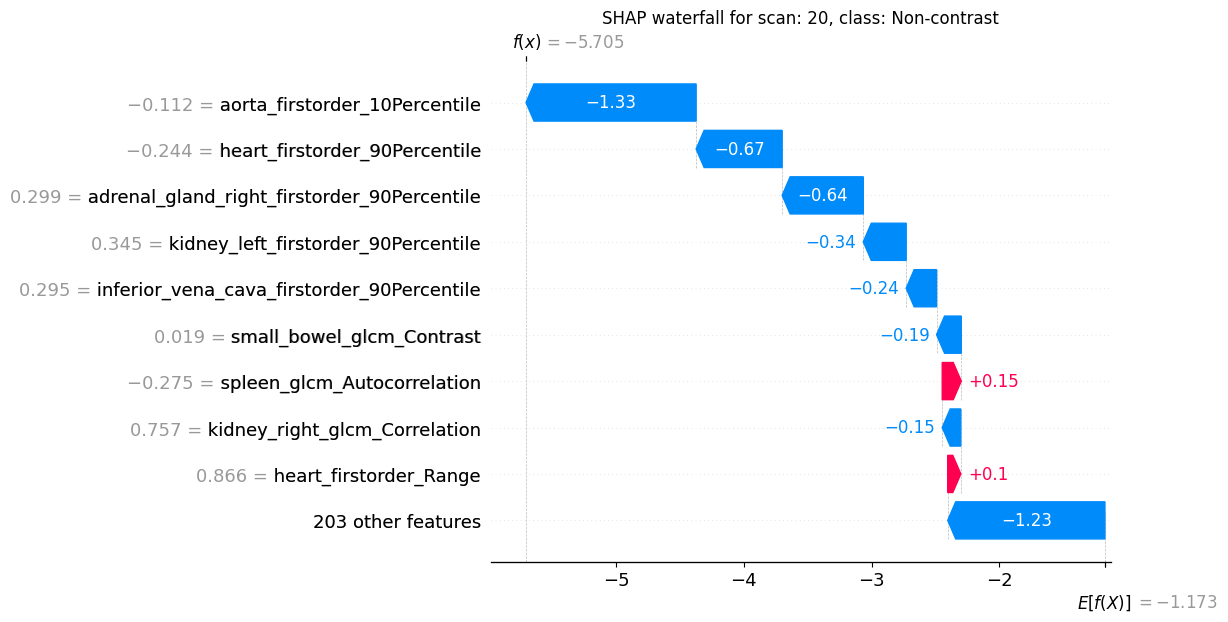

In [ ]:
i = 20  # index of sample => 1st sample
class_idx = 1

exp = shap.Explanation(
    values = shap_values.values[i, :, class_idx],
    base_values = shap_values.base_values[i, class_idx],
    data = X_test.iloc[i],
    feature_names = X_test.columns
)

plt.title(f"SHAP waterfall for scan: {i}, class: {contrast_le.classes_[class_idx]}", fontsize=12)
shap.plots.waterfall(exp)

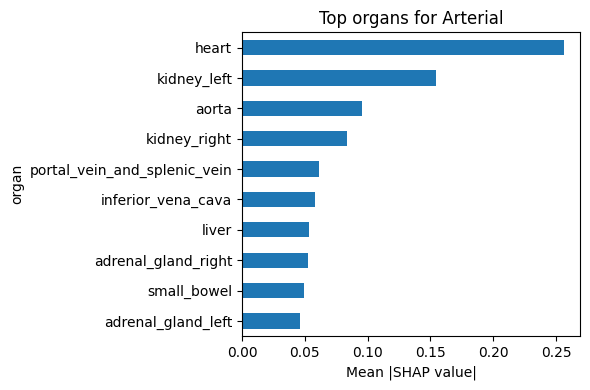

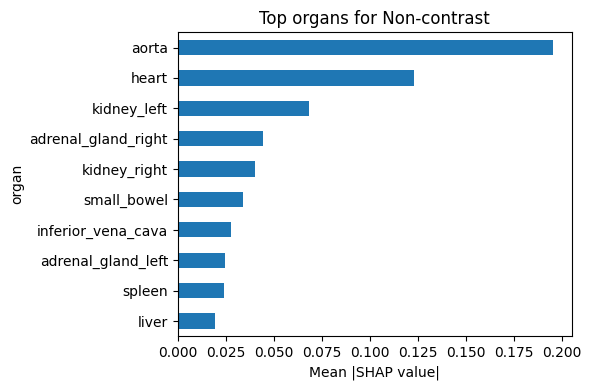

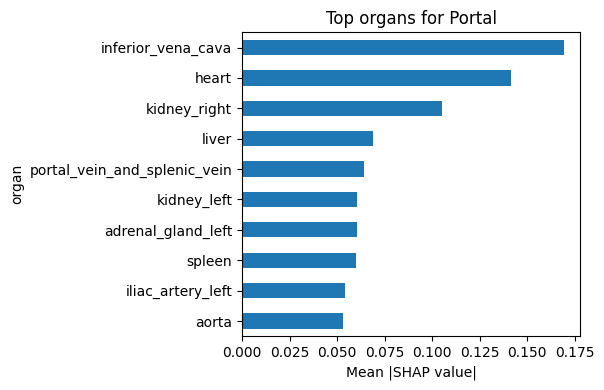


Top organs for ARTERIAL (vs portal):
                              arterial    portal  difference
organ                                                       
heart                         0.256260  0.141327    0.114933
kidney_left                   0.154118  0.060686    0.093431
aorta                         0.095668  0.053024    0.042644
small_bowel                   0.049591  0.039470    0.010121
iliac_vena_left               0.040873  0.035462    0.005411
adrenal_gland_right           0.052584  0.047592    0.004992
pancreas                      0.042426  0.040341    0.002084
iliac_artery_right            0.029302  0.027647    0.001655
portal_vein_and_splenic_vein  0.060972  0.064318   -0.003346
stomach                       0.024827  0.028513   -0.003686

Top organs for PORTAL (vs arterial):
                    arterial    portal  difference
organ                                             
inferior_vena_cava  0.057874  0.169272   -0.111398
iliac_vena_right    0.022501  0.046905 

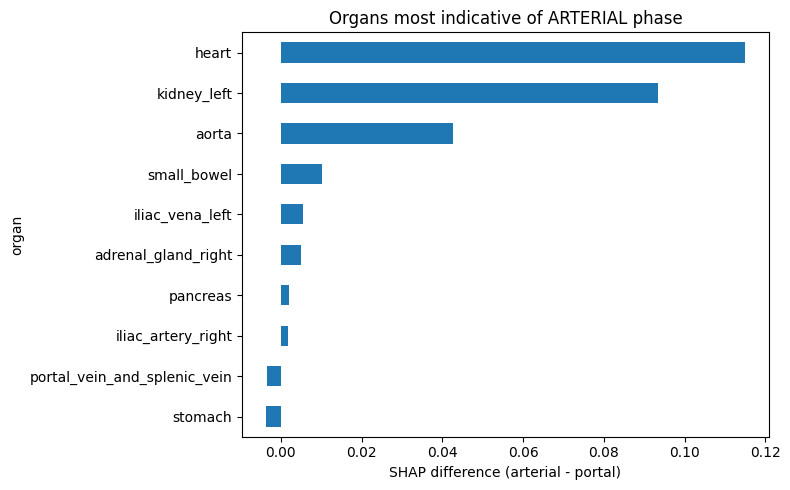

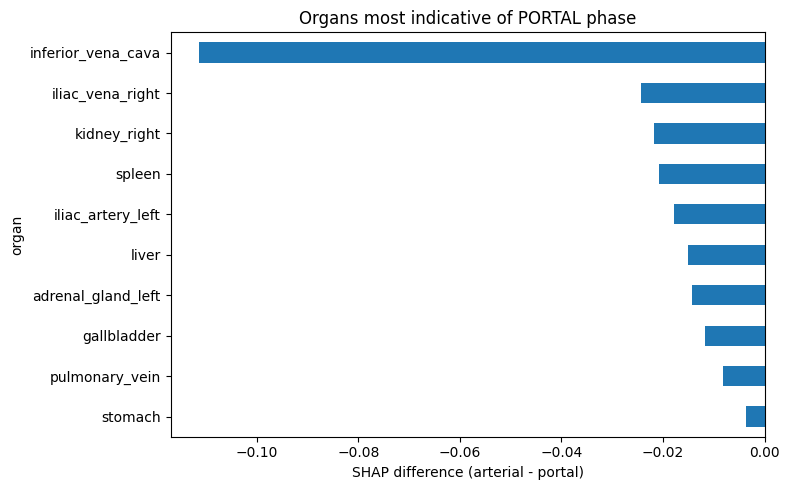

<Figure size 1000x500 with 0 Axes>

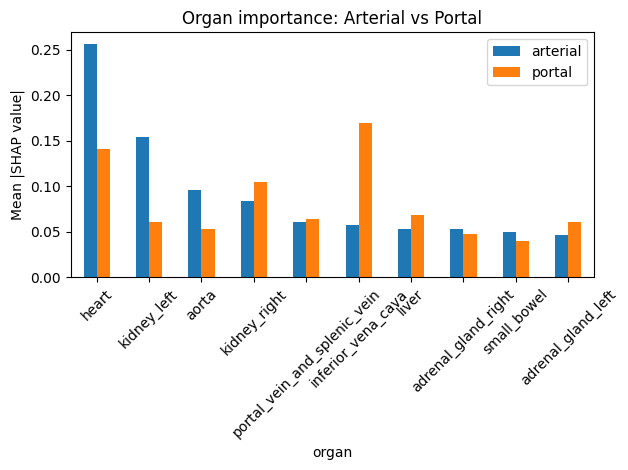

In [ ]:
feature_names = X_test.columns
import re

def extract_organ(feature_name):
    match = re.split(r'_(firstorder|glcm|glrlm|glszm|gldm|ngtdm|shape)', feature_name)
    return match[0]

organ_names = [extract_organ(col) for col in X_test.columns]


organ_importance_per_class = {}

for class_idx, class_name in enumerate(contrast_le.classes_):

    shap_class = shap_values.values[:, :, class_idx]

    # Mean absolute SHAP per feature
    mean_shap = np.abs(shap_class).mean(axis=0)

    df = pd.DataFrame({
        "feature": feature_names,
        "organ": organ_names,
        "importance": mean_shap
    })

    # Aggregate per organ (mean is preferred)
    organ_importance = (
        df.groupby("organ")["importance"]
        .mean()
        .sort_values(ascending=False)
    )

    organ_importance_per_class[class_name] = organ_importance

    # ----------------------------
    # Plot top organs per class
    # ----------------------------
    plt.figure(figsize=(6, 4))
    organ_importance.head(10).plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title(f"Top organs for {class_name}")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()


# ----------------------------
# 3. Arterial vs Portal comparison
# ----------------------------
classes = list(contrast_le.classes_)

arterial_idx = classes.index("Arterial")
portal_idx = classes.index("Portal")

shap_art = np.abs(shap_values.values[:, :, arterial_idx]).mean(axis=0)
shap_port = np.abs(shap_values.values[:, :, portal_idx]).mean(axis=0)

df_compare = pd.DataFrame({
    "feature": feature_names,
    "organ": organ_names,
    "arterial": shap_art,
    "portal": shap_port
})

# Aggregate per organ
organ_compare = df_compare.groupby("organ")[["arterial", "portal"]].mean()

# Difference (positive = more important for arterial)
organ_compare["difference"] = organ_compare["arterial"] - organ_compare["portal"]

# ----------------------------
# 4. Print top discriminative organs
# ----------------------------
print("\nTop organs for ARTERIAL (vs portal):")
print(organ_compare.sort_values("difference", ascending=False).head(10))

print("\nTop organs for PORTAL (vs arterial):")
print(organ_compare.sort_values("difference", ascending=True).head(10))


# ----------------------------
# 5. Plot comparison
# ----------------------------
plt.figure(figsize=(8, 5))
organ_compare.sort_values("difference", ascending=False).head(10)["difference"].plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Organs most indicative of ARTERIAL phase")
plt.xlabel("SHAP difference (arterial - portal)")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
organ_compare.sort_values("difference", ascending=True).head(10)["difference"].plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Organs most indicative of PORTAL phase")
plt.xlabel("SHAP difference (arterial - portal)")
plt.tight_layout()
plt.show()


# ----------------------------
# 6. Side-by-side plot
# ----------------------------
top_organs = organ_compare.sort_values("arterial", ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_organs[["arterial", "portal"]].plot(kind="bar")
plt.title("Organ importance: Arterial vs Portal")
plt.ylabel("Mean |SHAP value|")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualizations

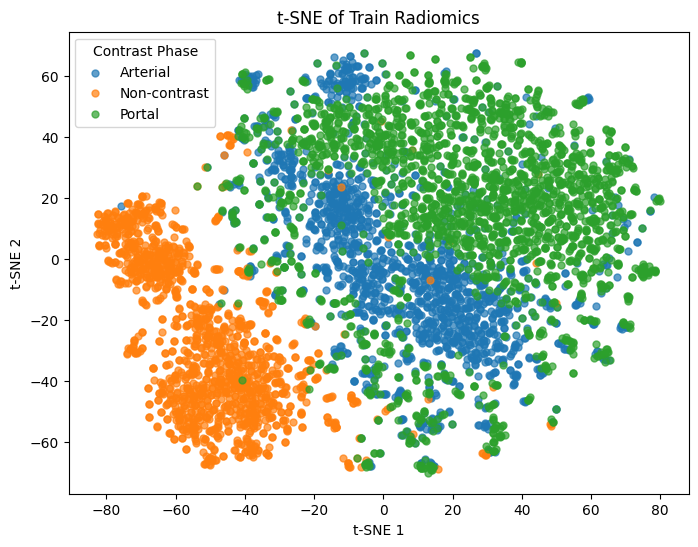

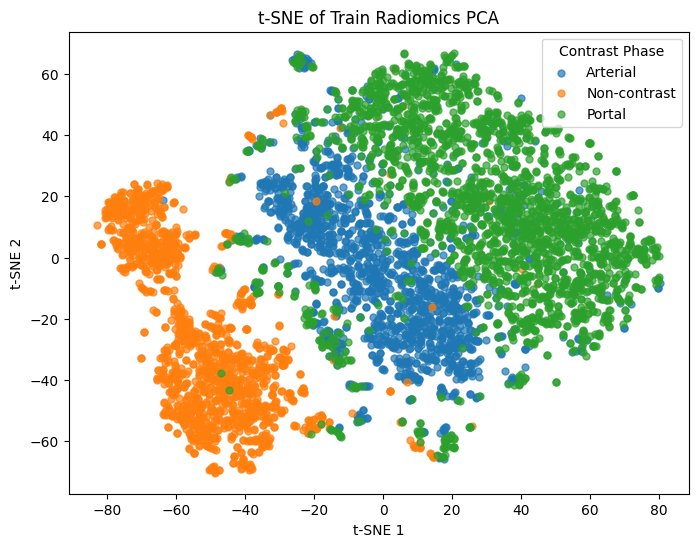

In [15]:
tsne_visual(X_train, y_train, contrast_le, "t-SNE of Train Radiomics")
tsne_visual(X_train_pca, y_train, contrast_le, "t-SNE of Train Radiomics PCA")

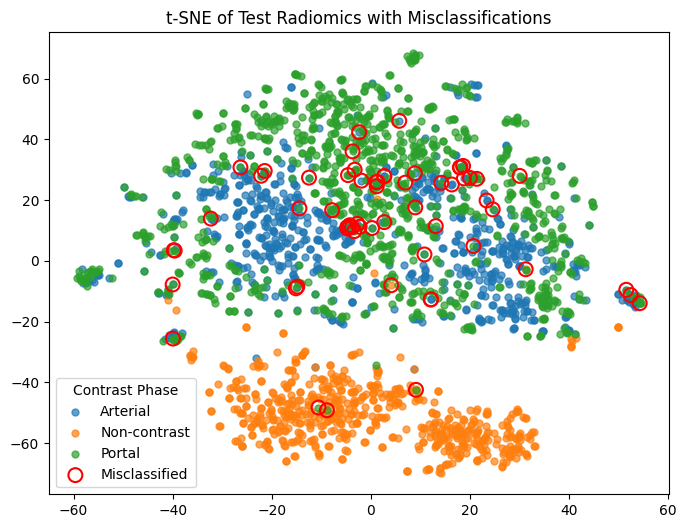

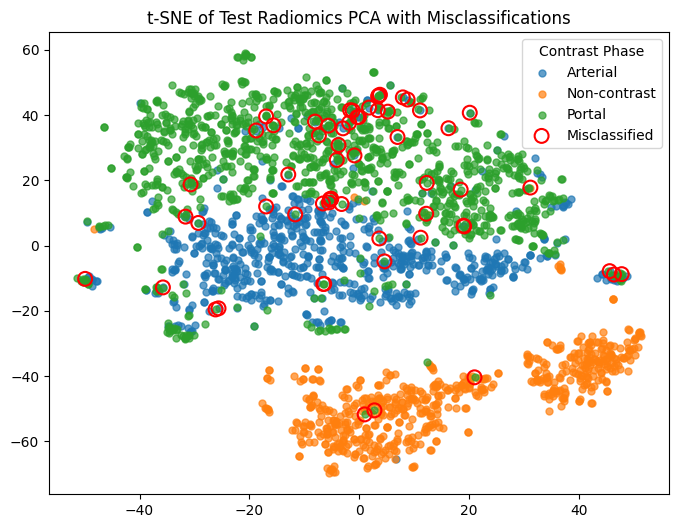

In [8]:
tsne_visual(X_test,
            y_test,
            contrast_le,
            title = "t-SNE of Test Radiomics with Misclassifications",
            misclassifications=True,
            predictions=GBT_pred)

tsne_visual(X_test_pca,
            y_test,
            contrast_le,
            title= "t-SNE of Test Radiomics PCA with Misclassifications",
            misclassifications=True,
            predictions=GBT_pred)

## Misclassifications

In [16]:
GBT_pred = predictions["GBT"]

In [19]:

def window_ct(img, center = 50, width = 300):
        low = center - width/2
        high = center + width/2
        return img.clip(low, high)

def show_misclass(misclass_data, orig_data, samples_per_class=3, label = 'contrast'):
    """
    Display misclassified images with true and predicted labels using
    'contrast' and 'pred_contrast' columns in misclass_data.

    misclass_data: pd.DataFrame
        Must contain 'MatchKey', 'contrast', and 'pred_contrast'.
    orig_data: pd.DataFrame
        Original dataframe with 'MatchKey' and 'server_folder'.
    samples_per_class: int
        Number of images to show per class.
    """

    # Merge folder paths
    misclass_data = misclass_data.merge(orig_data[['MatchKey', 'server_folder']], on='MatchKey', how='left')

    # Sample images per class
    rows = []
    for c in misclass_data[label].unique():
        subset = misclass_data[misclass_data[label] == c]
        rows.append(subset.sample(n=min(samples_per_class, len(subset))))

    selected_rows = pd.concat(rows).sort_values(label).reset_index(drop=True)

    file_list = selected_rows.MatchKey.tolist()
    folder_list = selected_rows.server_folder.tolist()

    # Load images
    images, _ = data_load(file_list, folder_list, organ_seg=False)

    

    # Plot images
    for _, group in selected_rows.groupby(label):

        plt.figure(figsize=(15, 5))

        for j, idx in enumerate(group.index):
            img = images[idx][0]
            slice_img = img[:, :, int(img.shape[-1] // 1.3)]

            plt.subplot(1, len(group), j + 1)
            plt.imshow(np.rot90(window_ct(slice_img), 1), cmap="gray")

            # Use contrast and pred_contrast columns
            true_label = selected_rows.loc[idx, label]
            pred_label = selected_rows.loc[idx, "pred_contrast"]
            plt.title(f"True:{true_label}\nPred: {pred_label}")
            plt.axis("off")

        plt.show()


In [20]:
import ipywidgets as widgets
from IPython.display import display
from radiomics_pipeline import data_load

def show_misclass_widget(misclass_data, orig_data, samples_per_class=3, label='contrast'):
    """
    Display misclassified images with an interactive slice slider.
    """

    # Merge folder paths
    misclass_data = misclass_data.merge(orig_data[['MatchKey', 'server_folder']], left_on="image", right_on='MatchKey', how='left')

    # Sample images per class
    rows = []
    for c in misclass_data[label].unique():
        subset = misclass_data[misclass_data[label] == c]
        rows.append(subset.sample(n=min(samples_per_class, len(subset))))

    selected_rows = pd.concat(rows).sort_values(label).reset_index(drop=True)

    file_list = selected_rows.image.tolist()
    folder_list = selected_rows.server_folder.tolist()

    # Load images
    images, _ = data_load(file_list, folder_list, organ_seg=False)

    max_slices = max(img[0].shape[-1] for img in images)

    # Create a slice slider widget
    slice_slider = widgets.IntSlider(
        value=max_slices // 2,
        min=0,
        max=max_slices - 1,
        step=1,
        description="Slice"
    )

    def update(slice_idx):
        """Redraw images for selected slice."""
        for _, group in selected_rows.groupby(label):
            plt.figure(figsize=(15, 5))

            for j, idx in enumerate(group.index):
                img = images[idx][0]
                slice_idx_use = min(slice_idx, img.shape[-1] - 1)
                slice_img = img[:, :, slice_idx_use]

                plt.subplot(1, len(group), j + 1)
                plt.imshow(np.rot90(window_ct(slice_img), 1), cmap="gray")

                true_label = selected_rows.loc[idx, label]
                pred_label = selected_rows.loc[idx, "pred_contrast"]
                plt.title(f"True:{true_label}\nPred: {pred_label}")
                plt.axis("off")

            plt.show()

    # Use interactive widget
    widgets.interact(update, slice_idx=slice_slider)

In [17]:
misclass_data = extract_misclass(
    y_test,
    GBT_pred,  
    test_processed,  
    contrast_le,                  
    X_test.index                # important
)
misclass_data.head()

,image,SubjectKeyRadiology,phase_timing,contrast,adrenal_gland_left_firstorder_10Percentile,adrenal_gland_left_firstorder_90Percentile,adrenal_gland_left_firstorder_Energy,adrenal_gland_left_firstorder_Entropy,adrenal_gland_left_firstorder_Kurtosis,adrenal_gland_left_firstorder_Minimum,...,stomach_firstorder_Entropy,stomach_firstorder_Maximum,stomach_firstorder_Median,stomach_firstorder_Minimum,stomach_glcm_Correlation,stomach_glszm_ZoneEntropy,stomach_glszm_SmallAreaEmphasis,stomach_glszm_GrayLevelNonUniformity,stomach_glszm_SizeZoneNonUniformity,pred_contrast
10,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,NKI-d23231-00-0005,Just Right,Arterial,1.454899,1.187198,0.825683,0.089085,0.181119,0.852501,...,1.296382,-0.157163,0.252880,-0.014708,-0.084282,0.828090,0.344827,-0.105244,0.711120,Portal
29,NKI-d23231-00-0010_20070213_kalina05_0018.nii.gz,NKI-d23231-00-0010,Just Right,Portal,-0.256865,-0.934769,-0.860664,-0.803112,-0.138793,0.230633,...,-1.386193,-0.375761,0.154181,0.105329,-0.919934,-0.146522,-0.766854,-0.390854,-0.813061,Non-contrast
141,NKI-d23231-00-0052_20130412_kalina14_0020.nii.gz,NKI-d23231-00-0052,Just Right,Portal,-0.962747,0.513557,-0.143907,1.575463,-0.530716,-0.295563,...,-0.772882,-0.285893,0.203530,-1.535175,0.639415,-1.451921,0.367432,1.619752,0.519785,Arterial
160,NKI-d23231-00-0052_20210402_kalina13_0004.nii.gz,NKI-d23231-00-0052,Just Right,Arterial,-1.139217,-0.463221,-0.956968,0.780556,-0.550609,-0.080301,...,-1.190661,-0.400049,-0.117242,-0.054720,0.521324,-1.484503,-0.009345,3.037109,1.534112,Portal
192,NKI-d23231-00-0053_20100427_kalina15_0015.nii.gz,NKI-d23231-00-0053,Just Right,Arterial,-1.880393,3.073390,1.079406,3.716951,-0.583900,-2.663444,...,1.632165,0.158589,0.384479,0.105329,0.386714,0.191702,0.073744,0.238043,0.510684,Portal


In [18]:
misclass_data.to_csv("/projects/net_contrast_classification/contrast_phase/data/radiomics_contrast_misclass.csv", index=False)

In [24]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/TS/TS_results.csv")
data['server_folder'] = np.where(
    data['exist_on_server'].notna(),
    "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET",
    "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server"
)

data['server_folder'].value_counts()

server_folder
/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET                  5447
/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server    3287
Name: count, dtype: int64

In [25]:
misclass_data.head()

,image,SubjectKeyRadiology,phase_timing,contrast,adrenal_gland_left_firstorder_10Percentile,adrenal_gland_left_firstorder_90Percentile,adrenal_gland_left_firstorder_Energy,adrenal_gland_left_firstorder_Entropy,adrenal_gland_left_firstorder_Kurtosis,adrenal_gland_left_firstorder_Minimum,...,stomach_firstorder_Entropy,stomach_firstorder_Maximum,stomach_firstorder_Median,stomach_firstorder_Minimum,stomach_glcm_Correlation,stomach_glszm_ZoneEntropy,stomach_glszm_SmallAreaEmphasis,stomach_glszm_GrayLevelNonUniformity,stomach_glszm_SizeZoneNonUniformity,pred_contrast
10,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,NKI-d23231-00-0005,Just Right,Arterial,1.455424,1.188326,0.826744,0.089149,0.181125,0.852617,...,1.296723,-0.157163,0.252907,-0.015016,-0.084225,0.828376,0.345143,-0.105911,0.710870,Portal
28,NKI-d23231-00-0010_20070213_kalina04_0018.nii.gz,NKI-d23231-00-0010,Too Early,Arterial,-0.044578,-0.698770,-0.655509,-0.732590,0.057062,-0.175637,...,-1.496633,-0.322400,0.187065,0.105089,-0.993516,0.220498,-1.367523,-0.573770,-0.958453,Non-contrast
29,NKI-d23231-00-0010_20070213_kalina05_0018.nii.gz,NKI-d23231-00-0010,Just Right,Portal,-0.256343,-0.934657,-0.860420,-0.802878,-0.138920,0.230882,...,-1.386033,-0.375860,0.154143,0.105089,-0.920018,-0.146407,-0.766564,-0.391359,-0.813451,Non-contrast
141,NKI-d23231-00-0052_20130412_kalina14_0020.nii.gz,NKI-d23231-00-0052,Just Right,Portal,-0.962226,0.514363,-0.143315,1.575243,-0.531005,-0.295201,...,-0.772681,-0.285951,0.203525,-1.536351,0.639594,-1.452037,0.367749,1.618108,0.519518,Arterial
160,NKI-d23231-00-0052_20210402_kalina13_0004.nii.gz,NKI-d23231-00-0052,Just Right,Arterial,-1.138697,-0.462883,-0.956771,0.780488,-0.550906,-0.079986,...,-1.190488,-0.400159,-0.117459,-0.055052,0.521483,-1.484624,-0.009037,3.034663,1.533938,Portal


In [18]:
show_misclass_widget(misclass_data, data)

interactive(children=(IntSlider(value=120, description='Slice', max=240), Output()), _dom_classes=('widget-int…

In [26]:
data.SliceThickness.value_counts()

SliceThickness
1.0    4307
1.5    3343
3.0     719
2.0     320
Name: count, dtype: int64

In [27]:
misclass_data_eval = misclass_data[["image",
                                    "contrast", 
                                    "pred_contrast",
                                    "phase_timing"]].merge(data,
                                                            left_on="image",
                                                            right_on="MatchKey",
                                                            how="left")

misclass_data_eval[["SubjectKeyRadiology",
                    "contrast_x",
                    "phase_timing_x",
                    "pred_contrast",
                    "DICOM_phase",
                    "TS_contrast",
                    "is_lesionfree",
                    "is_liver_imaged",
                    "ProtocolName",
                    "ConvolutionKernel",
                    "AcquisitionTime",
                    "SliceThickness"
                ]]

,SubjectKeyRadiology,contrast_x,phase_timing_x,pred_contrast,DICOM_phase,TS_contrast,is_lesionfree,is_liver_imaged,ProtocolName,ConvolutionKernel,AcquisitionTime,SliceThickness
0,NKI-d23231-00-0005,Arterial,Just Right,Portal,NaN,Portal,Yes,Yes,ABDOMEN + C 1.0 FC01,FC01,12:10:30.950000,1.0
1,NKI-d23231-00-0010,Arterial,Too Early,Non-contrast,Arterial,Portal,No,Yes,Lever A 2mm,B,11:29:4.000000,2.0
2,NKI-d23231-00-0010,Portal,Just Right,Non-contrast,NaN,Arterial,No,Yes,Abdomen +C 2mm,B,11:29:44.000000,2.0
3,NKI-d23231-00-0052,Portal,Just Right,Arterial,NaN,Portal,No,Partially,ABDOMEN + C 1.0 FC02,FC02,11:51:16.250000,1.0
4,NKI-d23231-00-0052,Arterial,Just Right,Portal,NaN,Portal,No,Yes,Body 1.0 CE Vol.,FC01,13:42:23.150000,1.0
5,NKI-d23231-00-0053,Arterial,Just Right,Portal,NaN,Portal,Yes,Partially,Thorax 1.5 B45f,B45f,15:47:35.044780,1.5
6,NKI-d23231-00-0067,Arterial,Just Right,Portal,NaN,Portal,No,Yes,ABDOMEN + C 1.0 FC01,FC01,14:36:27.500000,1.0
7,NKI-d23231-00-0102,Non-contrast,0.0,Portal,NaN,Non-contrast,No,0,Abdomen 1.5 B30f,B30f,15:32:48.225210,1.5
8,NKI-d23231-00-0102,Arterial,Just Right,Portal,NaN,Portal,No,Yes,Lever +C 1.5 B25f,B25f,15:31:46.756630,1.5
9,NKI-d23231-00-0109,Portal,Just Right,Non-contrast,Non-contrast,Non-contrast,No,Yes,Lever -C 1.5 B25f,B25f,15:10:56.432010,1.5


In [28]:
misclass_data_eval.is_lesionfree.value_counts()

is_lesionfree
No     42
Yes    15
Name: count, dtype: int64

In [29]:
misclass_data_eval.high_signal_to_noise.value_counts()

high_signal_to_noise
False    49
True      7
Name: count, dtype: int64

In [30]:
misclass_data_eval[misclass_data_eval.pred_contrast == misclass_data_eval.DICOM_phase][["SubjectKeyRadiology",
                                                                                        "contrast_x",
                                                                                        "pred_contrast",
                                                                                        "DICOM_phase",
                                                                                        "TS_contrast"]]

,SubjectKeyRadiology,contrast_x,pred_contrast,DICOM_phase,TS_contrast
9,NKI-d23231-00-0109,Portal,Non-contrast,Non-contrast,Non-contrast
21,NKI-d23231-00-0223,Arterial,Portal,Portal,Portal
41,NKI-d23231-00-0510,Portal,Arterial,Arterial,Portal
42,NKI-d23231-00-0511,Portal,Arterial,Arterial,Arterial
48,NKI-d23231-00-0610,Portal,Arterial,Arterial,Arterial
50,NKI-d23231-00-0663,Portal,Arterial,Arterial,Portal
55,NKI-d23231-00-0841,Arterial,Portal,Portal,Portal


# Phase Timing Classification

## Modeling and Evaluation

In [9]:
train_data_timing = train_processed[(train_processed.contrast != "Non-contrast") 
                                 & ~(train_processed.phase_timing.isin(["0.0", "Non-contrast"]))]

train_data_timing['contrast_timing'] = (train_data_timing["contrast"].str.cat(train_data_timing["phase_timing"], sep=" "))
train_data_timing["contrast_timing"] = train_data_timing["contrast_timing"].astype(str).str.strip()
print("Train data class distribution:\n",train_data_timing.contrast_timing.value_counts(), "\n")

test_data_timing = test_processed[(test_processed.contrast != "Non-contrast") 
                                 & ~(test_processed.phase_timing.isin(["0.0", "Non-contrast"]))]

test_data_timing['contrast_timing'] = (test_data_timing["contrast"].str.cat(test_data_timing["phase_timing"], sep=" "))
test_data_timing["contrast_timing"] = test_data_timing["contrast_timing"].astype(str).str.strip()
print("Test data class distribution:\n", test_data_timing.contrast_timing.value_counts())

Train data class distribution:
 contrast_timing
Portal Just Right      2442
Arterial Just Right    1090
Arterial Too Early      564
Arterial Too Late        90
Portal Too Early         82
Portal Too Late          42
Name: count, dtype: int64 

Test data class distribution:
 contrast_timing
Portal Just Right      1075
Arterial Just Right     477
Arterial Too Early      234
Portal Too Early         35
Arterial Too Late        25
Portal Too Late          13
Name: count, dtype: int64


In [10]:
timing_le = LabelEncoder()

X_train_timing, y_train_timing = train_data_timing.iloc[:, 4:-1], timing_le.fit_transform(train_data_timing.contrast_timing)
X_test_timing, y_test_timing = test_data_timing.iloc[:, 4:-1], timing_le.fit_transform(test_data_timing.contrast_timing)

print(f"Shape of train data: {X_train_timing.shape}\nShape of train labels: {y_train_timing.shape}")
print(f"Shape of test data: {X_test_timing.shape}\nShape of test labels: {y_test_timing.shape}")

Shape of train data: (4310, 211)
Shape of train labels: (4310,)
Shape of test data: (1859, 211)
Shape of test labels: (1859,)


In [11]:
train_data_timing.contrast_timing

0          Portal Too Early
1         Portal Just Right
3         Portal Just Right
4          Portal Too Early
5        Arterial Too Early
               ...         
5764      Portal Just Right
5765    Arterial Just Right
5766      Portal Just Right
5767    Arterial Just Right
5768      Portal Just Right
Name: contrast_timing, Length: 4310, dtype: str

In [12]:
models = train_tree_models(X_train_timing, y_train_timing)
GPT_pred_timing ,_ = evaluate_model(models["GBT"], X_test_timing, y_test_timing, timing_le)

Accuracy of XGBClassifier: 0.87789

Classification report for XGBClassifier:
                     precision    recall  f1-score   support

Arterial Just Right       0.82      0.83      0.83       477
 Arterial Too Early       0.77      0.76      0.76       234
  Arterial Too Late       0.00      0.00      0.00        25
  Portal Just Right       0.93      0.99      0.96      1075
   Portal Too Early       0.40      0.06      0.10        35
    Portal Too Late       0.00      0.00      0.00        13

           accuracy                           0.88      1859
          macro avg       0.49      0.44      0.44      1859
       weighted avg       0.85      0.88      0.86      1859



Predicted contrast,Arterial Just Right,Arterial Too Early,Arterial Too Late,Portal Just Right,Portal Too Early,Portal Too Late,All
True contrast,,,,,,,
Arterial Just Right,394,54,1,27,1,0,477
Arterial Too Early,56,177,0,1,0,0,234
Arterial Too Late,15,0,0,10,0,0,25
Portal Just Right,10,0,3,1059,2,1,1075
Portal Too Early,3,0,0,30,2,0,35
Portal Too Late,0,0,0,13,0,0,13
All,478,231,4,1140,5,1,1859


### Class weights

In [57]:

# Compute balanced class weights
classes = np.unique(y_train_timing)
class_weights = compute_class_weight("balanced", classes=classes, y=y_train_timing)
sample_weights = np.array([class_weights[c] for c in y_train_timing])
print(class_weights)
print(sample_weights)


# Train XGBClassifier
model = XGBClassifier(
    objective="multi:softprob",
    num_class=6,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)

model.fit(X_train_timing, y_train_timing, sample_weight=sample_weights)

# Predictions
y_pred_probs = model.predict_proba(X_test_timing)  # shape: (n_samples, 6)
y_pred = y_pred_probs.argmax(axis=1)


print(classification_report(y_test_timing, y_pred))

[ 0.65257125  1.27666667  8.56300813  0.2947803   8.45983936 17.55416667]
[8.45983936 0.2947803  0.2947803  ... 0.2947803  0.65257125 0.2947803 ]
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       493
           1       0.72      0.79      0.75       248
           2       0.50      0.09      0.15        33
           3       0.94      0.98      0.96      1150
           4       0.17      0.06      0.09        34
           5       0.17      0.06      0.08        18

    accuracy                           0.88      1976
   macro avg       0.55      0.46      0.48      1976
weighted avg       0.86      0.88      0.86      1976



### Ordinal Regression

In [41]:
phase_mapping = {"Arterial Too Early": 0,
                 "Arterial Just Right": 1,
                 "Arterial Too Late": 2,
                 "Portal Too Early": 3,
                 "Portal Just Right": 4,
                 "Portal Too Late": 5,
                 }


y_train_timing = np.array(train_data_timing.contrast_timing.map(phase_mapping))
y_test_timing = np.array(test_data_timing.contrast_timing.map(phase_mapping))

print("Unique timing labels:", np.unique(y_train_timing),"Bin count:", np.bincount(y_train_timing))


sample_weights = np.array([class_weights[c] * (1 + c / 5) for c in y_train_timing])


model = XGBClassifier(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    random_state=0
)

model.fit(X_train_timing, y_train_timing, sample_weight=sample_weights)

y_pred_cont = model.predict(X_test_timing)
y_pred = np.clip(np.round(y_pred_cont), 0, 5).astype(int)

print(classification_report(y_test_timing, y_pred))
pd.crosstab(y_test_timing, y_pred)

Unique timing labels: [0 1 2 3 4 5] Bin count: [ 550 1076   82   83 2382   40]
              precision    recall  f1-score   support

           0       0.78      0.73      0.75       248
           1       0.83      0.85      0.84       493
           2       0.67      0.06      0.11        33
           3       0.00      0.00      0.00        34
           4       0.92      0.99      0.95      1150
           5       0.00      0.00      0.00        18

    accuracy                           0.88      1976
   macro avg       0.53      0.44      0.44      1976
weighted avg       0.85      0.88      0.86      1976



col_0,0,1,2,3,4,5
row_0,,,,,,
0,180,64,0,0,4,0
1,48,421,0,2,22,0
2,0,12,2,1,18,0
3,0,3,0,0,31,0
4,3,6,1,1,1135,4
5,0,0,0,0,18,0


Takeaway: 
- Arterial too early - is mostly mistaken for arterial just right or for portal just right because of the class majority
- Arterial just right - is mostly mistaken for arterial too early (might be some similarities) or portal just right (class majority)
- Arterial too late, portal too early and portal too late - completely mistaken for the majority classes 

However, ordinal structure is relatively kept because the classes are mistaken with the majority class from the same contrast phase

### Optimal vs Suboptimal

In [60]:
optimality_le = LabelEncoder()

train_data_timing["timing_optimality"] = train_data_timing.phase_timing.apply(lambda x: "Optimal" 
                                                                              if x == "Just Right"
                                                                              else "Suboptimal")

test_data_timing["timing_optimality"] = test_data_timing.phase_timing.apply(lambda x: "Optimal" 
                                                                              if x == "Just Right"
                                                                              else "Suboptimal")


train_data_timing['contrast_timing'] = (train_data_timing["contrast"].str.cat(train_data_timing["timing_optimality"], sep=" "))
train_data_timing["contrast_timing"] = train_data_timing["contrast_timing"].astype(str).str.strip()

test_data_timing['contrast_timing'] = (test_data_timing["contrast"].str.cat(test_data_timing["timing_optimality"], sep=" "))
test_data_timing["contrast_timing"] = test_data_timing["contrast_timing"].astype(str).str.strip()

y_train_timing = optimality_le.fit_transform(train_data_timing.contrast_timing)
y_test_timing = optimality_le.fit_transform(test_data_timing.contrast_timing)
print("Unique timing labels:", np.unique(y_train_timing),"Bin count:", np.bincount(y_train_timing), "->", np.unique(optimality_le.inverse_transform(y_train_timing)))

models = train_tree_models(X_train_timing, y_train_timing)
predictions,_ = evaluate_model(models, X_test_timing, y_test_timing, optimality_le)

Unique timing labels: [0 1 2 3] Bin count: [1076  632 2382  123] -> ['Arterial Optimal' 'Arterial Suboptimal' 'Portal Optimal'
 'Portal Suboptimal']
Accuracy of DT: 0.84868
Accuracy of RF: 0.86690
Accuracy of GBT: 0.87449

Classification report for GBT:
                     precision    recall  f1-score   support

   Arterial Optimal       0.82      0.82      0.82       493
Arterial Suboptimal       0.73      0.67      0.70       281
     Portal Optimal       0.93      0.99      0.96      1150
  Portal Suboptimal       0.11      0.02      0.03        52

           accuracy                           0.87      1976
          macro avg       0.65      0.62      0.63      1976
       weighted avg       0.85      0.87      0.86      1976



Predicted contrast,Arterial Optimal,Arterial Suboptimal,Portal Optimal,Portal Suboptimal,All
True contrast,,,,,
Arterial Optimal,405,67,19,2,493
Arterial Suboptimal,73,189,18,1,281
Portal Optimal,9,3,1133,5,1150
Portal Suboptimal,4,0,47,1,52
All,491,259,1217,9,1976


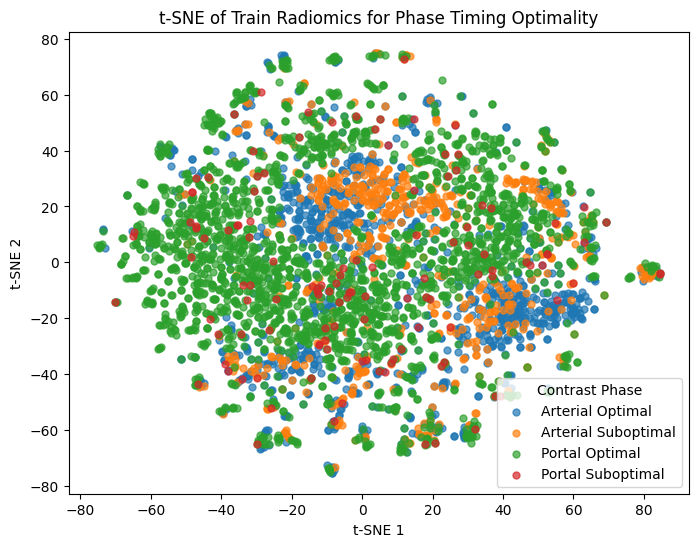

In [61]:
tsne_visual(X_train_timing, y_train_timing,optimality_le, "t-SNE of Train Radiomics for Phase Timing Optimality")

### Balanced Sampling

In [31]:
sampled_train_df = train_data_timing.groupby('contrast_timing', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 400), random_state=42))
sampled_train_df['contrast_timing'] = sampled_train_df["contrast"].str.cat(sampled_train_df["phase_timing"], sep=" ")
sampled_train_df["contrast_timing"] = sampled_train_df["contrast_timing"].astype(str).str.strip()
sampled_train_df

,image,SubjectKeyRadiology,phase_timing,contrast,adrenal_gland_left_firstorder_10Percentile,adrenal_gland_left_firstorder_90Percentile,adrenal_gland_left_firstorder_Energy,adrenal_gland_left_firstorder_Entropy,adrenal_gland_left_firstorder_Kurtosis,adrenal_gland_left_firstorder_Minimum,...,stomach_firstorder_Entropy,stomach_firstorder_Maximum,stomach_firstorder_Median,stomach_firstorder_Minimum,stomach_glcm_Correlation,stomach_glszm_ZoneEntropy,stomach_glszm_SmallAreaEmphasis,stomach_glszm_GrayLevelNonUniformity,stomach_glszm_SizeZoneNonUniformity,contrast_timing
5564,NKI-d23231-00-0863_20230714_kalina99_5706.nii.gz,NKI-d23231-00-0863,Just Right,Arterial,0.519605,0.143055,-0.284556,-0.467141,-0.161839,0.613321,...,-1.296114,-0.055151,0.359804,0.425428,-1.253479,-0.617018,-0.669757,-0.464770,-0.906464,Arterial Just Right
2958,NKI-d23231-00-0338_20130903_kalina99_1810.nii.gz,NKI-d23231-00-0338,Just Right,Arterial,0.554899,0.042009,0.235115,-0.487620,-0.250020,0.469813,...,1.289559,0.003142,0.466728,0.325397,0.515018,1.086120,-0.285706,-0.837986,-0.698413,Arterial Just Right
3876,NKI-d23231-00-0460_20140825_kalina99_3122.nii.gz,NKI-d23231-00-0460,Just Right,Arterial,-0.045100,0.917742,0.439369,1.057917,-0.416817,0.063207,...,1.130084,0.221739,0.976673,0.045311,0.841353,1.537335,-0.852316,-0.571620,-0.203279,Arterial Just Right
4013,NKI-d23231-00-0483_20190405_kalina99_3380.nii.gz,NKI-d23231-00-0483,Just Right,Arterial,-0.292159,1.052470,1.069460,1.319875,-0.155924,-0.726086,...,-1.351717,1.147135,0.014357,0.105329,-0.319029,-1.417475,-2.287437,3.407689,0.416570,Arterial Just Right
4696,NKI-d23231-00-0647_20230615_kalina99_4479.nii.gz,NKI-d23231-00-0647,Just Right,Arterial,0.131370,1.945043,1.326682,1.383473,-0.143373,0.134961,...,1.490418,-0.103728,0.080156,0.105329,0.353348,1.068319,0.317947,-0.712483,-0.251813,Arterial Just Right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2615,NKI-d23231-00-0306_20200323_kalina99_1344.nii.gz,NKI-d23231-00-0306,Too Late,Portal,-0.327453,-0.126401,-0.247255,0.489339,-0.064215,-0.247727,...,0.122698,-0.351472,0.170630,0.105329,0.207913,-0.765995,-0.209236,-0.675986,-1.025159,Portal Too Late
3593,NKI-d23231-00-0420_20140704_kalina99_2728.nii.gz,NKI-d23231-00-0420,Too Late,Portal,-0.045100,0.109373,-0.235766,0.084086,-0.083835,0.015371,...,0.032012,-0.242173,0.121281,0.105329,0.305448,0.185420,0.005584,-0.293651,-0.209453,Portal Too Late
897,NKI-d23231-00-0105_20061013_giovanni01_0123.ni...,NKI-d23231-00-0105,Too Late,Portal,-0.115688,0.715649,1.457103,1.090468,-0.169694,-1.132692,...,-0.104442,-0.319897,-0.026768,0.105329,0.478903,-0.396867,-0.366904,1.107632,0.569409,Portal Too Late
1566,NKI-d23231-00-0193_20070726_giovanni01_0290.ni...,NKI-d23231-00-0193,Too Late,Portal,0.611370,0.156528,-0.181892,-0.318820,0.078745,0.589403,...,1.363426,-0.295608,0.162406,0.105329,-0.641640,0.035857,1.768725,-1.258632,-1.276857,Portal Too Late


In [32]:
timing_le = LabelEncoder()

X_train_timing, y_train_timing = sampled_train_df.iloc[:, 4:-1], timing_le.fit_transform(sampled_train_df.contrast_timing)
X_test_timing, y_test_timing = test_data_timing.iloc[:, 4:-1], timing_le.fit_transform(test_data_timing.contrast_timing)

print(f"Shape of train data: {X_train_timing.shape}\nShape of train labels: {y_train_timing.shape}")
print(f"Shape of test data: {X_test_timing.shape}\nShape of test labels: {y_test_timing.shape}")

Shape of train data: (1403, 212)
Shape of train labels: (1403,)
Shape of test data: (1974, 212)
Shape of test labels: (1974,)


In [33]:
models = train_tree_models(X_train_timing, y_train_timing)
predictions,_ = evaluate_model(models, X_test_timing, y_test_timing, timing_le)

Accuracy of DT: 0.73911
Accuracy of RF: 0.85512
Accuracy of GBT: 0.83536

Classification report for GBT:
                     precision    recall  f1-score   support

Arterial Just Right       0.85      0.73      0.79       493
 Arterial Too Early       0.64      0.89      0.74       248
  Arterial Too Late       0.19      0.15      0.17        33
  Portal Just Right       0.95      0.92      0.93      1148
   Portal Too Early       0.18      0.26      0.21        34
    Portal Too Late       0.12      0.17      0.14        18

           accuracy                           0.84      1974
          macro avg       0.49      0.52      0.50      1974
       weighted avg       0.85      0.84      0.84      1974



Predicted contrast,Arterial Just Right,Arterial Too Early,Arterial Too Late,Portal Just Right,Portal Too Early,Portal Too Late,All
True contrast,,,,,,,
Arterial Just Right,359,114,5,11,4,0,493
Arterial Too Early,27,220,0,1,0,0,248
Arterial Too Late,12,0,5,11,5,0,33
Portal Just Right,20,8,15,1053,30,22,1148
Portal Too Early,2,1,2,19,9,1,34
Portal Too Late,1,0,0,11,3,3,18
All,421,343,27,1106,51,26,1974


## Explanations

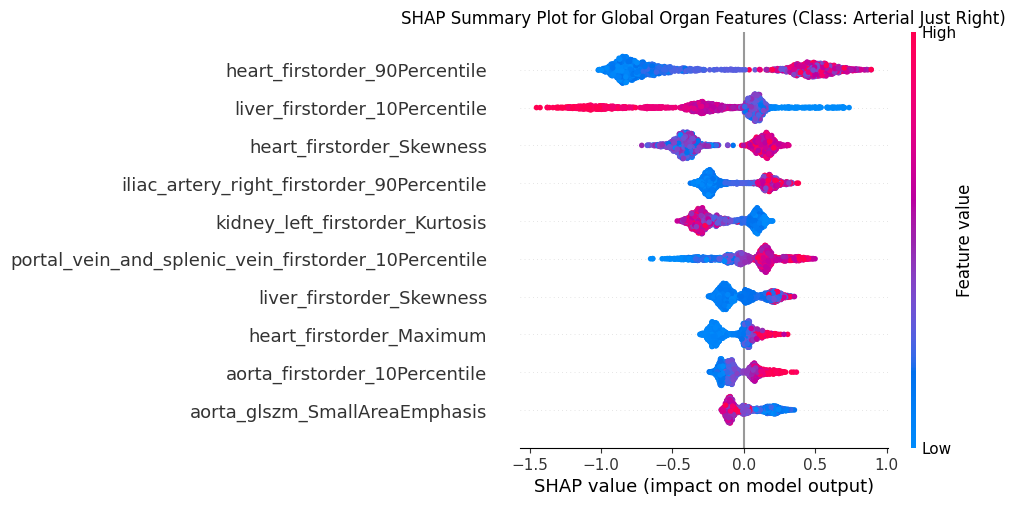

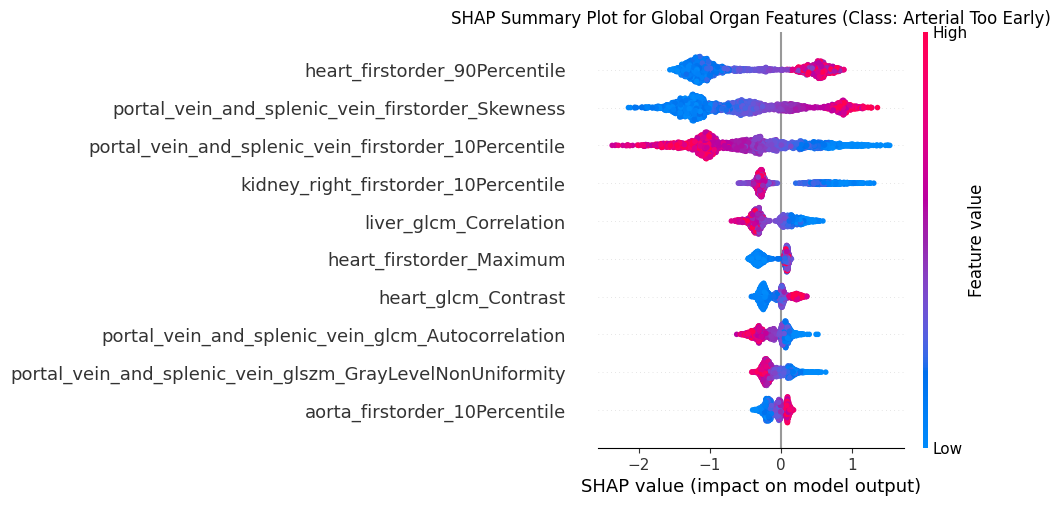

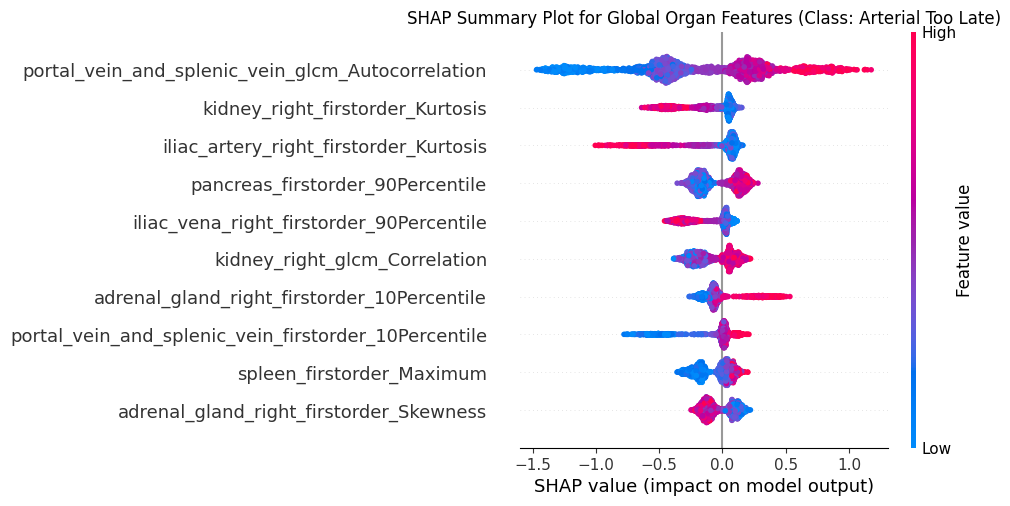

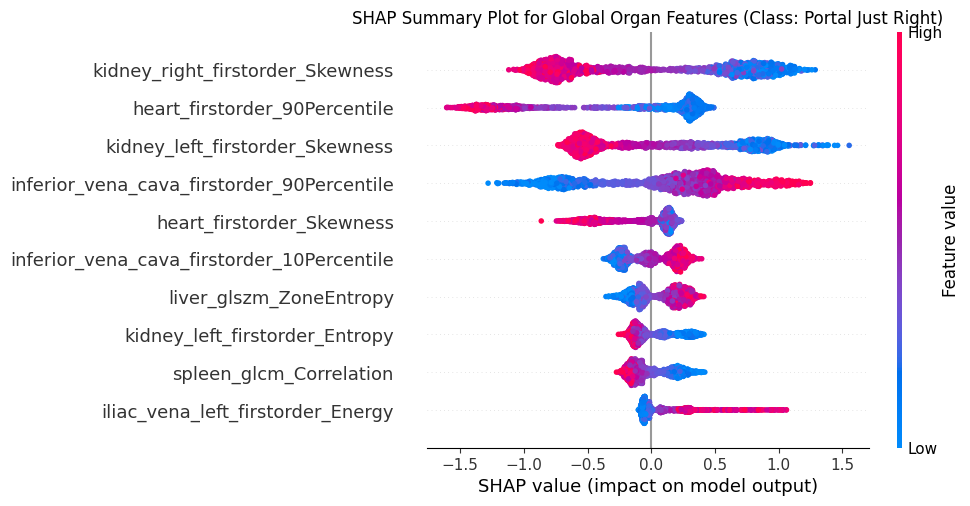

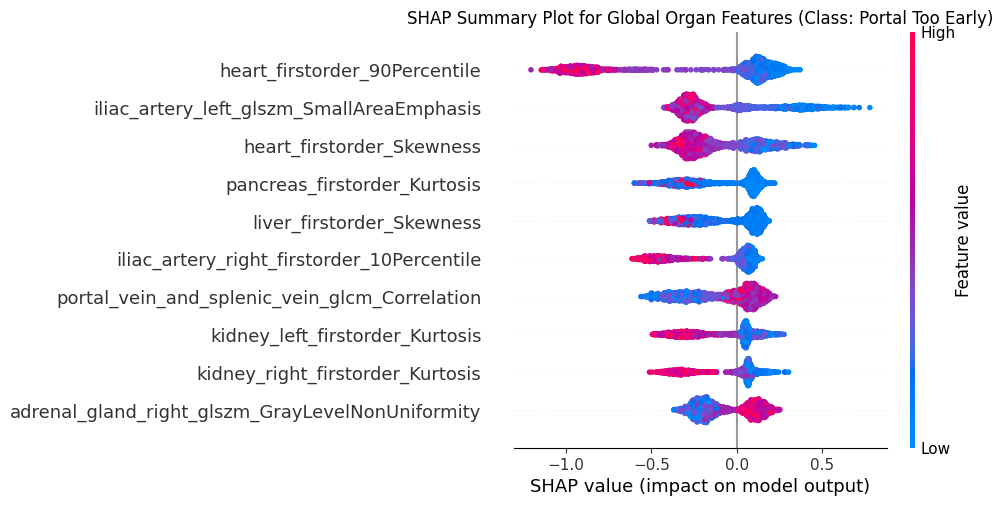

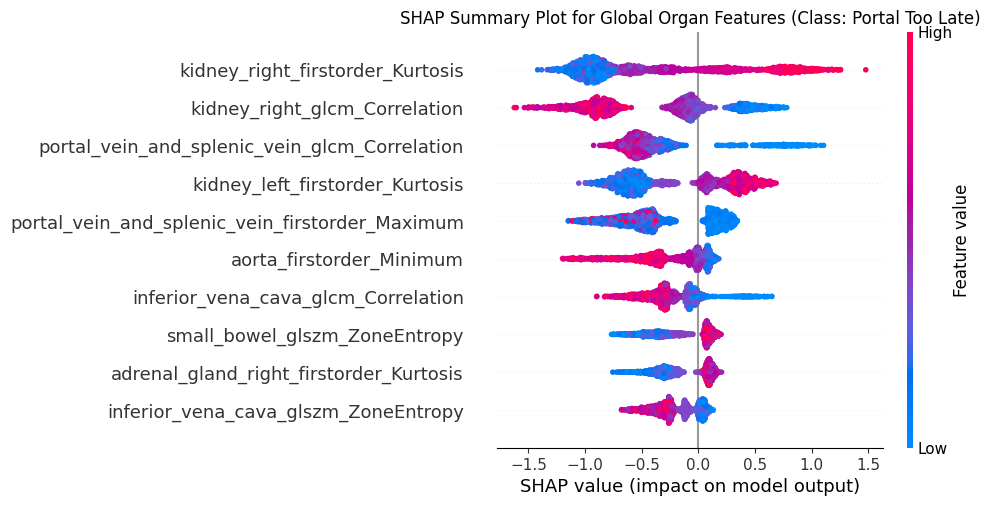

In [58]:
# GBT = models['GBT']

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_timing)


for contrast_class in range(len(timing_le.classes_)):
    shap.summary_plot(
        shap_values.values[:, :, contrast_class]
        , X_test_timing
        , max_display = 10
        , feature_names=X_test_timing.columns
        , plot_size=(10, 5)
        , show = False

    )

    plt.title(f"SHAP Summary Plot for Global Organ Features (Class: {timing_le.classes_[contrast_class]})", fontsize=12)
    plt.show()

"Portal Too Late" relies more on Second-order features (GLCM, GLRLM, etc.):
	•	capture texture patterns
	•	are high-dimensional and noisy
	•	often become dominant when:
	•	first-order features are not discriminative
	•	model is “searching” for weak signals

For rare classes:
→ model is overfitting to weak texture patterns
→ not learning a strong physiological signal

## Misclassifications

In [46]:
# GBT_pred_timing = predictions["GBT"]

misclass_data = extract_misclass(
    y_test_timing,
    y_pred,  
    test_data_timing,  
    timing_le,                  
    X_test_timing.index                # important
)
misclass_data.head()

,image,SubjectKeyRadiology,phase_timing,contrast,adrenal_gland_left_firstorder_10Percentile,adrenal_gland_left_firstorder_90Percentile,adrenal_gland_left_firstorder_Energy,adrenal_gland_left_firstorder_Entropy,adrenal_gland_left_firstorder_Kurtosis,adrenal_gland_left_firstorder_Minimum,...,stomach_firstorder_Maximum,stomach_firstorder_Median,stomach_firstorder_Minimum,stomach_glcm_Correlation,stomach_glszm_ZoneEntropy,stomach_glszm_SmallAreaEmphasis,stomach_glszm_GrayLevelNonUniformity,stomach_glszm_SizeZoneNonUniformity,contrast_timing,pred_contrast
0,NKI-d23231-00-0005_20071116_kalina99_0005.nii.gz,NKI-d23231-00-0005,Too Late,Portal,1.084835,-0.496581,-1.055439,-2.368681,0.707978,1.378700,...,-0.538667,-0.018694,0.725633,0.040929,0.257560,-0.812183,-0.627110,-0.796870,Portal Too Late,Portal Just Right
7,NKI-d23231-00-0005_20120618_kalina12_0050.nii.gz,NKI-d23231-00-0005,Too Early,Arterial,-0.048107,-0.563977,-0.733332,-0.685196,-0.095048,0.709139,...,-0.205762,0.261138,-0.995877,0.593019,1.144063,0.078745,-0.716424,-0.336266,Arterial Too Early,Arterial Just Right
8,NKI-d23231-00-0005_20120618_kalina99_0009.nii.gz,NKI-d23231-00-0005,Too Early,Portal,0.449540,0.615457,0.039042,0.171732,-0.415085,0.565662,...,-0.208192,0.458666,-1.176035,0.585212,0.977514,0.085656,-0.617513,-0.255597,Portal Too Early,Portal Just Right
10,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,NKI-d23231-00-0005,Just Right,Arterial,1.455424,1.188326,0.826744,0.089149,0.181125,0.852617,...,-0.157163,0.252907,-0.015016,-0.084225,0.828376,0.345143,-0.105911,0.710870,Arterial Just Right,Portal Just Right
14,NKI-d23231-00-0005_20181015_kalina03_0022.nii.gz,NKI-d23231-00-0005,Too Early,Portal,1.367188,0.615457,0.497655,-0.729938,0.242373,0.804791,...,-0.271371,-0.076307,0.165142,0.312715,1.032070,-0.409809,-0.344345,0.049263,Portal Too Early,Portal Just Right


In [21]:
show_misclass_widget(misclass_data, data, label = "contrast_timing")

interactive(children=(IntSlider(value=95, description='Slice', max=189), Output()), _dom_classes=('widget-inte…

## Visualizations

In [14]:
from sklearn.decomposition import PCA

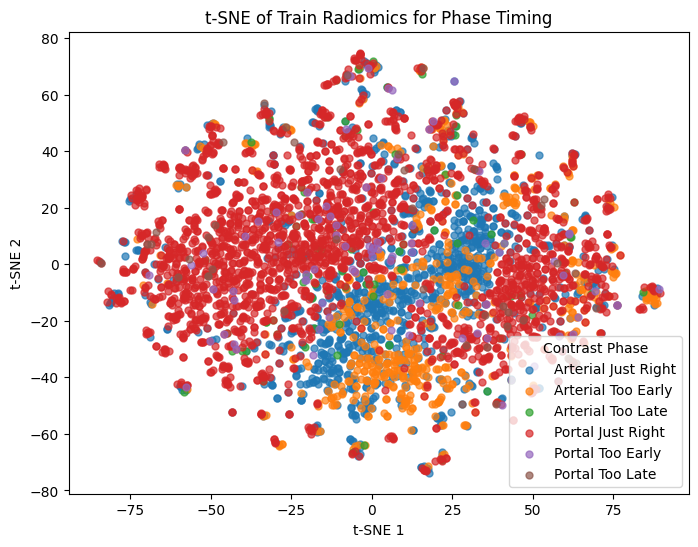

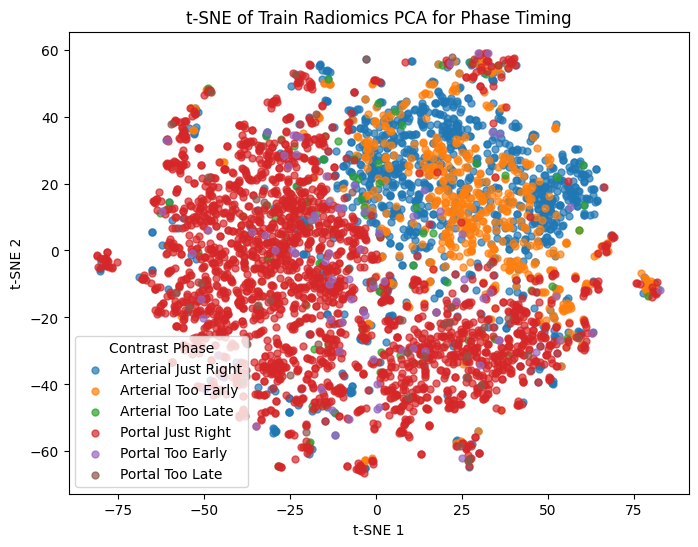

In [ ]:
tsne_visual(X_train_timing, y_train_timing,timing_le, "t-SNE of Train Radiomics for Phase Timing")
train_pca_timing = PCA(n_components=30, random_state = 42).fit_transform(X_train_timing)
tsne_visual(train_pca_timing, y_train_timing,timing_le, "t-SNE of Train Radiomics PCA for Phase Timing")

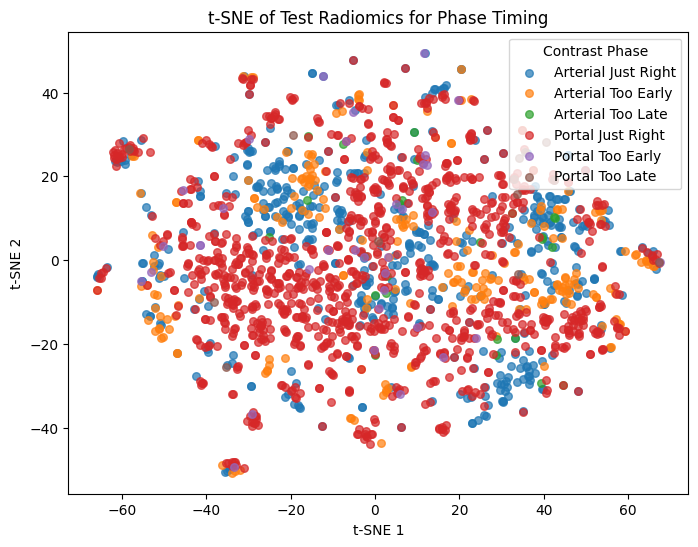

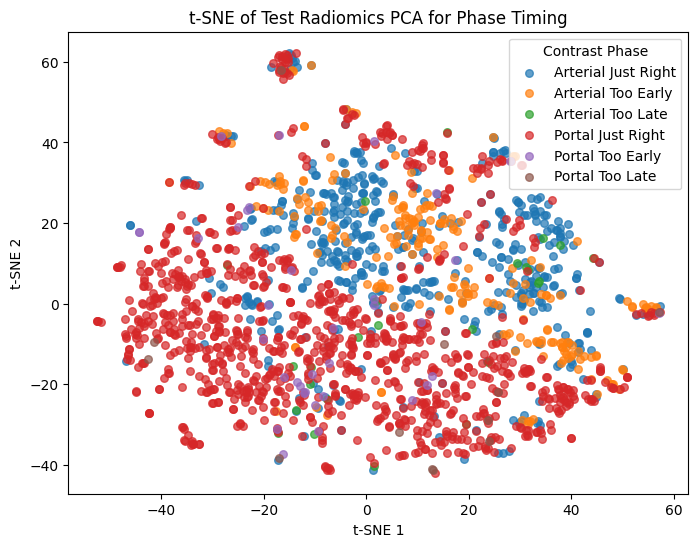

In [16]:
tsne_visual(X_test_timing, y_test_timing,timing_le, "t-SNE of Test Radiomics for Phase Timing", scatter_size=30)
test_pca_timing = PCA(n_components=30, random_state = 42).fit_transform(X_test_timing)
tsne_visual(test_pca_timing, y_test_timing,timing_le, "t-SNE of Test Radiomics PCA for Phase Timing", scatter_size=30)

Radiomics features do NOT create a clean separation between timing classes
Especially:
	•	Early vs optimal vs late are not forming distinct manifolds
	•	Minority classes are embedded inside majority regions

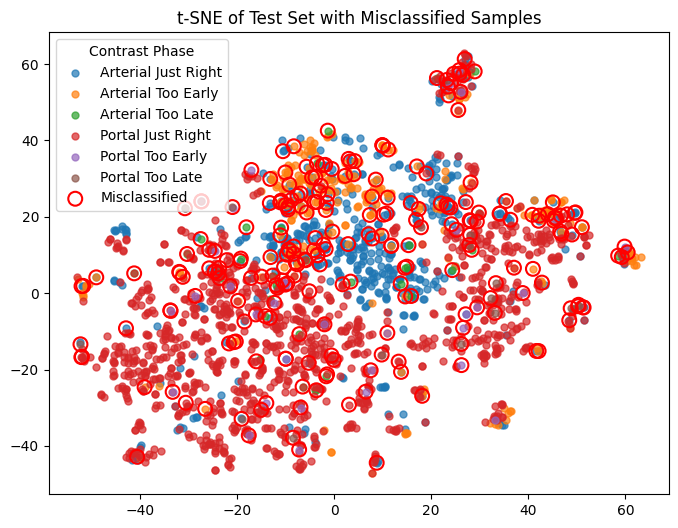

In [ ]:


tsne_visual(test_pca_timing,
            y_test_timing,
            timing_le,
            "t-SNE of Test Radiomics PCA for Phase Timing",
            misclassifications=True,
            predictions=y_pred)

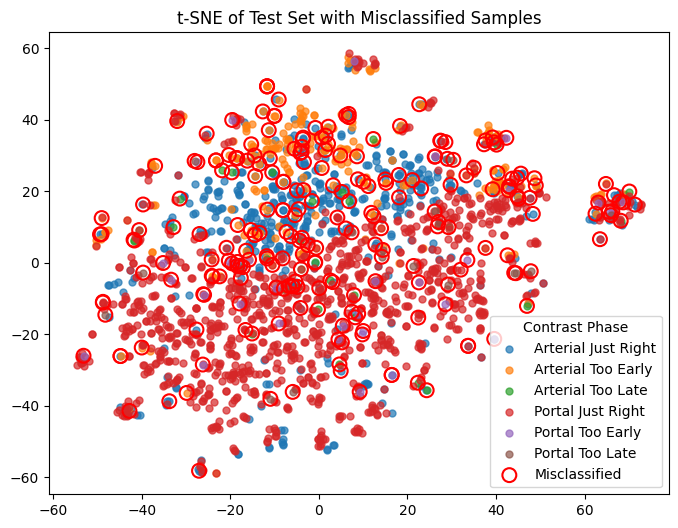

In [ ]:
tsne_visual(X_test_timing,
            y_test_timing,
            timing_le,
            "t-SNE of Test Radiomics for Phase Timing",
            misclassifications=True,
            predictions=GBT_pred)

# PCA

In [27]:
from data_preprocessing import PCA_formatting
train_pca = PCA_formatting(X_train_pca, train_processed)
test_pca = PCA_formatting(X_test_pca, test_processed)

train_pca

,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,...,PCA_21,PCA_22,PCA_23,PCA_24,PCA_25,PCA_26,PCA_27,PCA_28,PCA_29,PCA_30
0,1.125082,1.900427,0.194411,4.139634,-1.792700,0.319090,1.195311,0.664961,0.900958,0.648036,...,-0.255754,-0.249238,-0.705738,-0.654281,0.056165,1.341792,0.087289,-0.099210,-0.072117,0.591430
1,2.336418,0.702817,-0.774617,3.655397,-1.102603,0.223994,1.009821,0.924799,2.303150,0.480098,...,0.913020,1.108655,0.641111,0.285391,1.821488,-0.311680,-0.572512,0.600429,-0.312925,-0.180124
2,-4.661348,-7.623607,-4.377060,0.850455,-0.291278,0.359849,-1.942701,-0.223482,4.909420,2.897639,...,11.539871,6.147245,-2.091090,2.096970,4.878554,-0.829594,-3.738071,5.182501,1.380057,-0.231077
3,7.875120,-5.150695,-2.217713,2.371615,-0.780846,-1.207076,0.460775,0.250638,-1.514827,-1.418813,...,0.791292,0.731770,0.449121,0.348418,-0.667677,0.188351,-0.358158,-0.504446,-0.930938,-0.241793
4,8.864310,-4.360372,-7.803318,4.459831,-1.153244,-0.565291,-3.969503,-0.998518,-1.171573,-0.837713,...,0.247083,0.615173,-0.077550,-1.967564,-1.418988,-0.620940,0.421506,-1.454219,-0.292150,0.369185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5667,-0.103470,-0.123065,3.504716,2.099608,0.098718,-0.876874,0.766058,-1.193370,0.923795,0.023729,...,-0.532332,-0.669089,-0.931125,-0.529781,0.135744,0.007396,-0.142294,0.333731,-0.356360,0.812259
5668,4.619964,4.001494,0.140830,-1.838469,-1.012041,1.832476,0.726162,-3.109308,0.242573,-0.292859,...,-0.290698,-1.053166,0.840183,0.935580,-1.730760,-1.654599,-1.383162,-1.203538,0.586750,1.752333
5669,2.972664,0.598667,2.699444,2.730616,2.114768,0.244747,1.804674,-2.639588,0.493162,-0.003797,...,-0.851318,-1.188763,0.061746,0.932522,-1.027601,-1.276936,-1.135877,-1.124996,0.502199,0.279688
5670,7.806028,8.191723,-2.965057,0.875650,-0.503895,2.543795,0.856054,-3.782109,-0.975067,-0.716310,...,-0.161766,-1.748410,1.367689,0.898661,-2.172375,-2.011756,-1.516968,-1.029458,1.006128,1.853044


In [28]:
print(f"Shape of train data: {train_pca.shape}\nShape of train labels: {y_train.shape}")
print(f"Shape of test data: {test_pca.shape}\nShape of test labels: {y_test.shape}")

Shape of train data: (5672, 30)
Shape of train labels: (5672,)
Shape of test data: (2661, 30)
Shape of test labels: (2661,)


In [29]:
models = train_tree_models(train_pca, y_train)
predictions = evaluate_model(models, test_pca, y_test, contrast_le)

Accuracy of DT: 0.91432
Accuracy of RF: 0.92672
Accuracy of GBT: 0.95566

Classification report for GBT:
              precision    recall  f1-score   support

    Arterial       0.94      0.92      0.93       776
Non-contrast       0.99      0.98      0.99       683
      Portal       0.94      0.96      0.95      1202

    accuracy                           0.96      2661
   macro avg       0.96      0.96      0.96      2661
weighted avg       0.96      0.96      0.96      2661



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,715,2,59,776
Non-contrast,3,670,10,683
Portal,40,4,1158,1202
All,758,676,1227,2661


In [ ]:
# GBT = models['GBT']

# explainer = shap.TreeExplainer(GBT)
# shap_values = explainer(train_pca)


# for contrast_class in range(len(contrast_le.classes_)):
#     shap.summary_plot(
#         shap_values.values[:, :, contrast_class]
#         , train_pca
#         , max_display = 10
#         , feature_names=train_pca.columns
#         , plot_size=(10, 5)
#         , show = False
#         # , order=shap_values.abs.max(0)
#     )

#     plt.title(f"SHAP Summary Plot for Global Organ Features (Class: {contrast_le.classes_[contrast_class]})", fontsize=12)
#     plt.show()